## Example uses of the package

In this example notebook, you will find example uses of the *process_file* function on the different battery test types that are implemented.  

Basically, the function has three steps:  
- Preprocessing the file by reading and calculating useful columns such as *Cycle*, *State* and *Capacity*  
- Finding every types of tests available in the data  
- For each type of test, extracting and plotting battery characteristiques over its State of Charge (SOC)  

##
## GITT Tests

GITT *(Galvanostatic Intermittent Titration Technique)* is a test where the battery is cycled by applying current pulses between rests.  
In this case, the data contains only GITT cycling and the parameters extracted are the diffusion coefficients and the internal resistance.  

File : example_file_GITT.parquet
Length : 20862255
Preprocessing Time : 106.93471002578735
Find Test Time : 191.40428376197815
Test : GITT ; Length : 20769192
       Pulse  Cycle    TestTime       SOC   Voltage  Diffusion Coefficient  \
Pulse      0      1    46801.00  1.000000  2.484417           7.915816e-16   
Pulse      1      1    53999.98  0.980011  0.575001           3.010686e-16   
Pulse      2      1    61199.98  0.960011  0.379431           2.457276e-16   
Pulse      3      1    68399.98  0.940010  0.272730           1.544933e-16   
Pulse      4      1    75599.98  0.920010  0.216829           3.283266e-17   
...      ...    ...         ...       ...       ...                    ...   
Pulse    391      4  2692799.98  0.880001  0.216267           3.698408e-17   
Pulse    392      4  2699099.98  0.900001  0.217590           3.897789e-17   
Pulse    393      4  2705399.98  0.920000  0.219228           5.162642e-16   
Pulse    394      4  2711699.98  0.940000  0.236643          

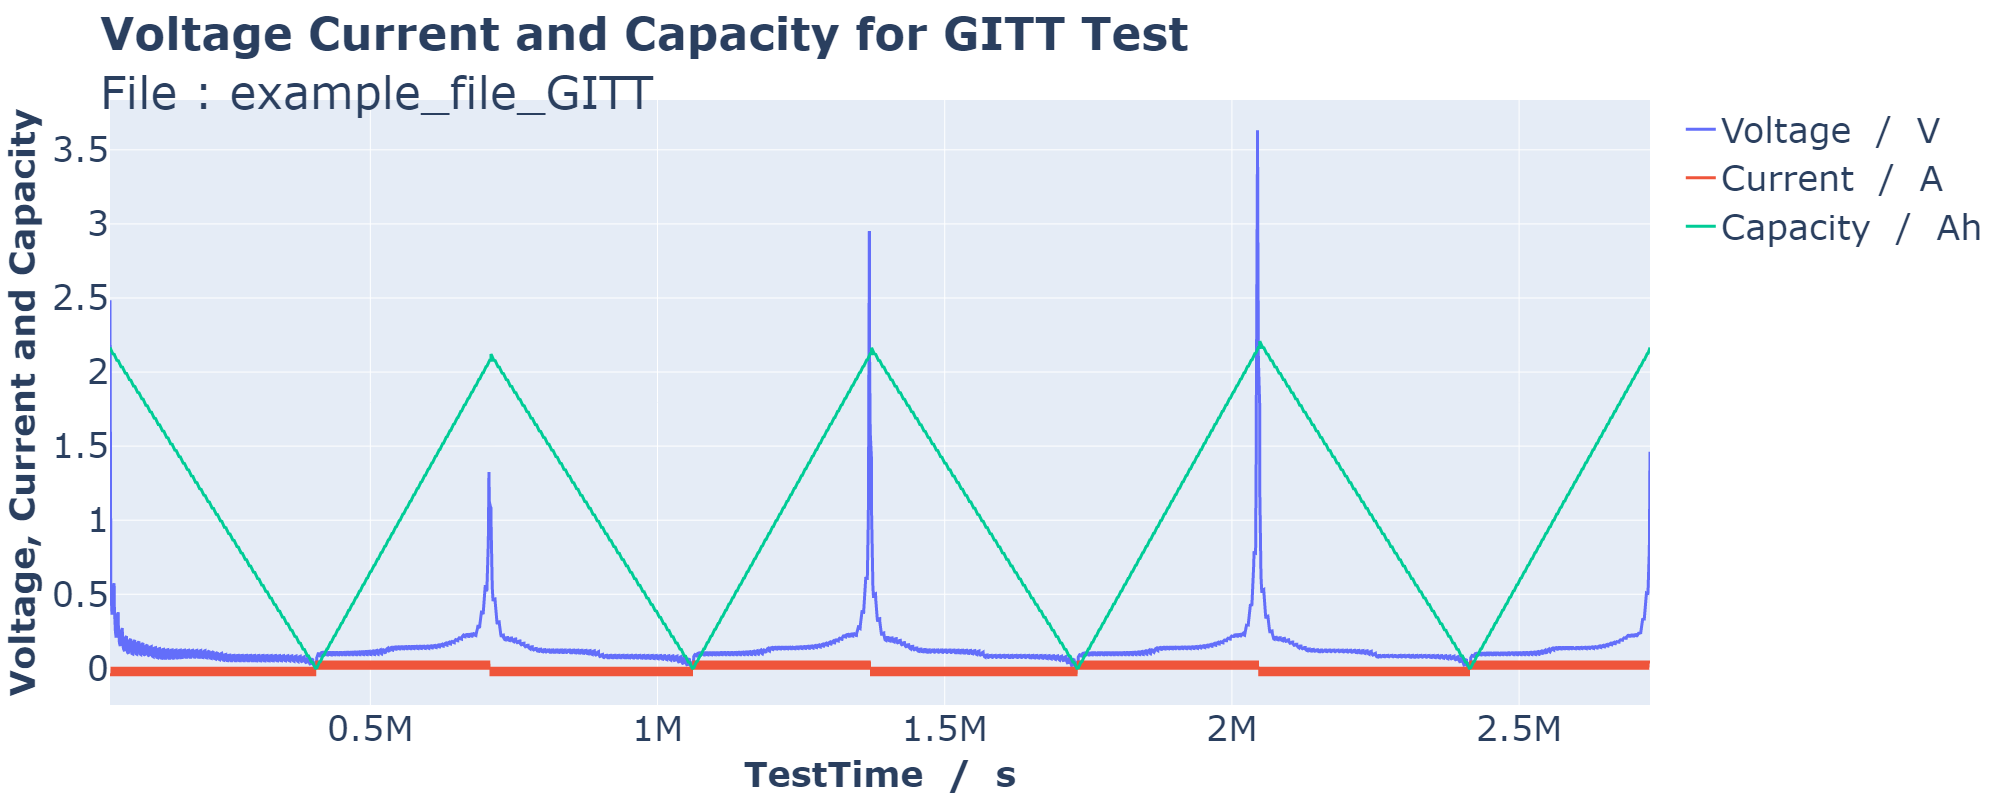

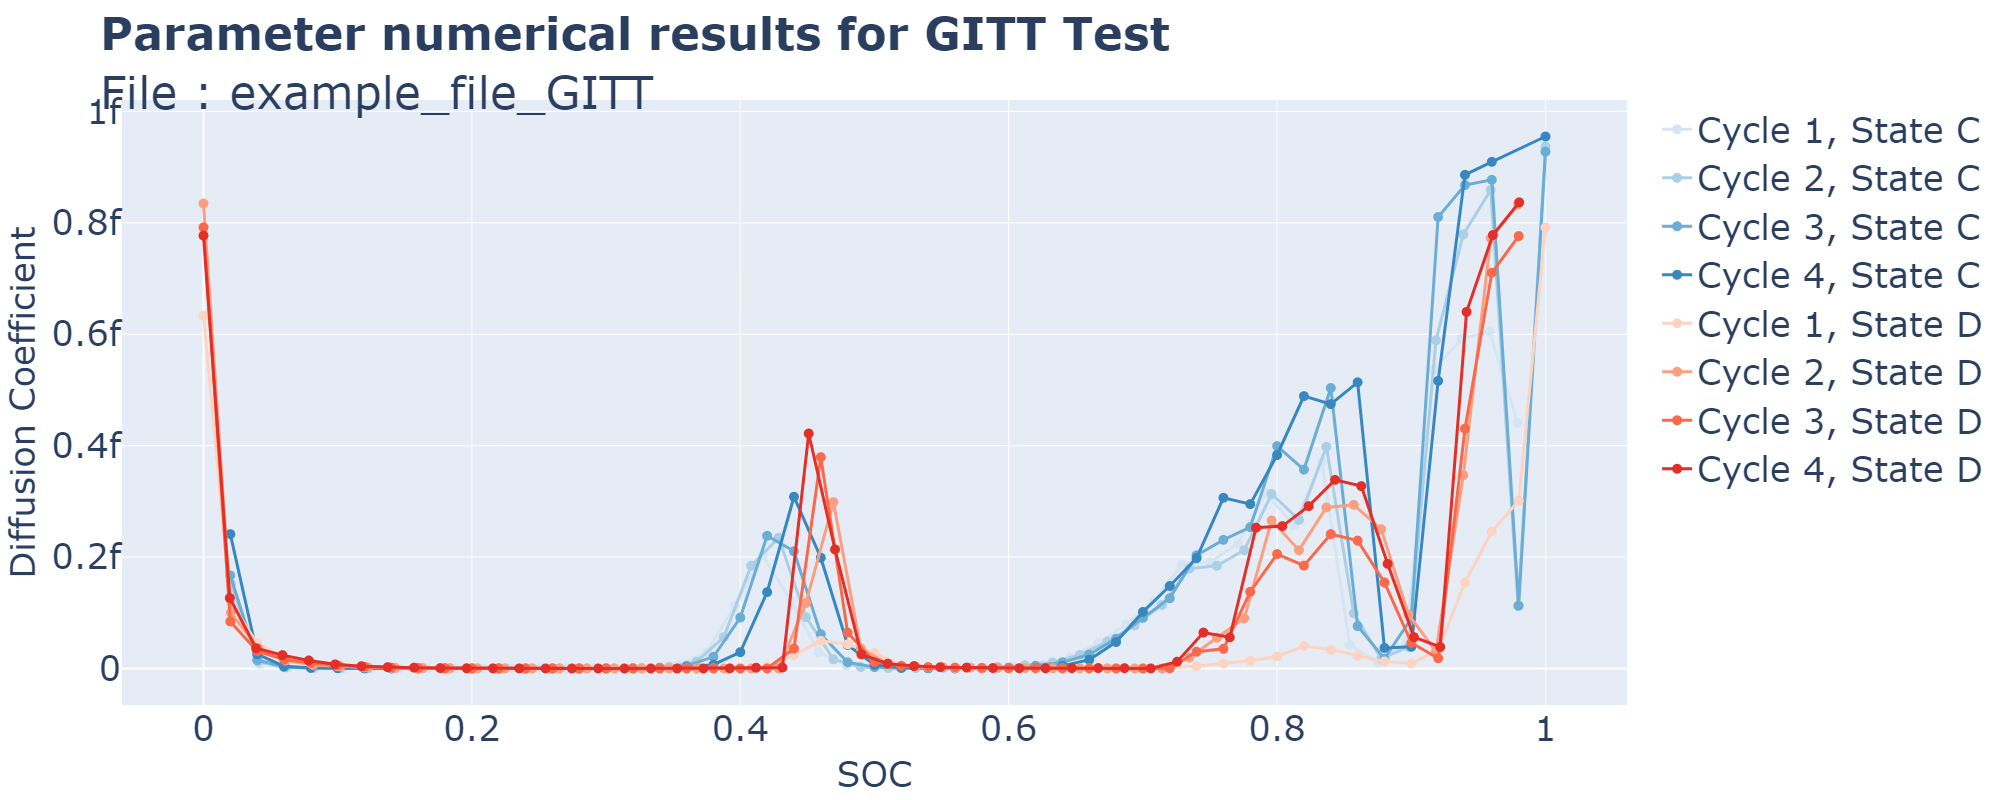

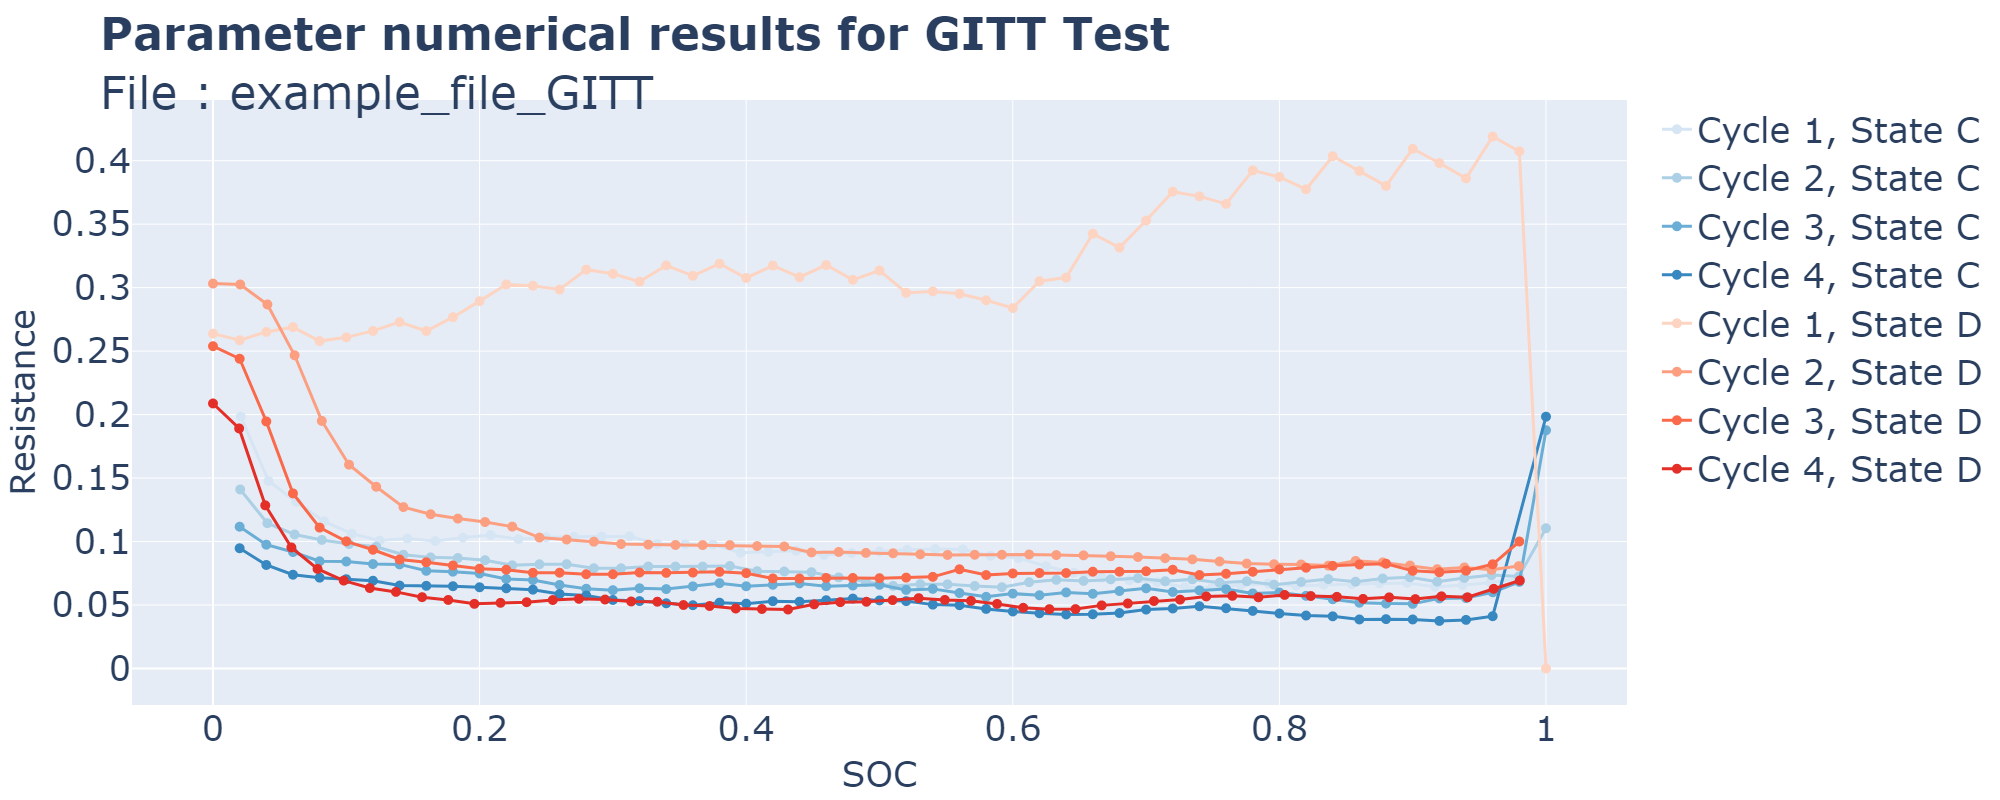

GITT Time : 67.7316882610321
Total Time : 378.9157886505127


In [ ]:
from BatteryDataAnalysis import process_file

file_path_GITT = 'C:/Examples/example_file_GITT.parquet'
df, result_dict = process_file(file_path_GITT, png=True)

##
## ICI Tests

ICI *(Intermittent Current Interruption)* test is composed of successive rest pulses are applied during the cycling, similarly to current pulses for GITT Tests  
The difference with GITT is the relaxation rate which is smaller for ICI.   

In this case, the data contains only ICI cycling and the parameters extracted are the diffusion coefficients and the internal resistance.  
Also, the voltage column is named *'Ewe/V'* which can't be guessed by the fuzzy matching, so we have to specify the column name in a Dict.

File : example_file_ICI.parquet
Length : 1473720
Preprocessing Time : 20.8307363986969
Find Test Time : 66.92448377609253
Test : ICI ; Length : 1473719
       Pulse  Cycle      TestTime       SOC   Voltage  Diffusion Coefficient  \
Pulse      1      0  2.999994e+02  0.007712  3.597049           4.069951e-11   
Pulse      2      0  6.099991e+02  0.015425  3.600956           1.270357e-11   
Pulse      3      0  9.199989e+02  0.023138  3.602941           3.124965e-12   
Pulse      4      0  1.229999e+03  0.030851  3.604182           3.690240e-12   
Pulse      5      0  1.539998e+03  0.038564  3.605041           7.013435e-12   
...      ...    ...           ...       ...       ...                    ...   
Pulse  13554     56  4.219626e+06  0.951931  4.213180           9.710987e-09   
Pulse  13555     56  4.219936e+06  0.960827  4.219154           8.403364e-09   
Pulse  13556     56  4.220246e+06  0.969724  4.225758           9.690374e-09   
Pulse  13557     56  4.220556e+06  0.978622  4.2

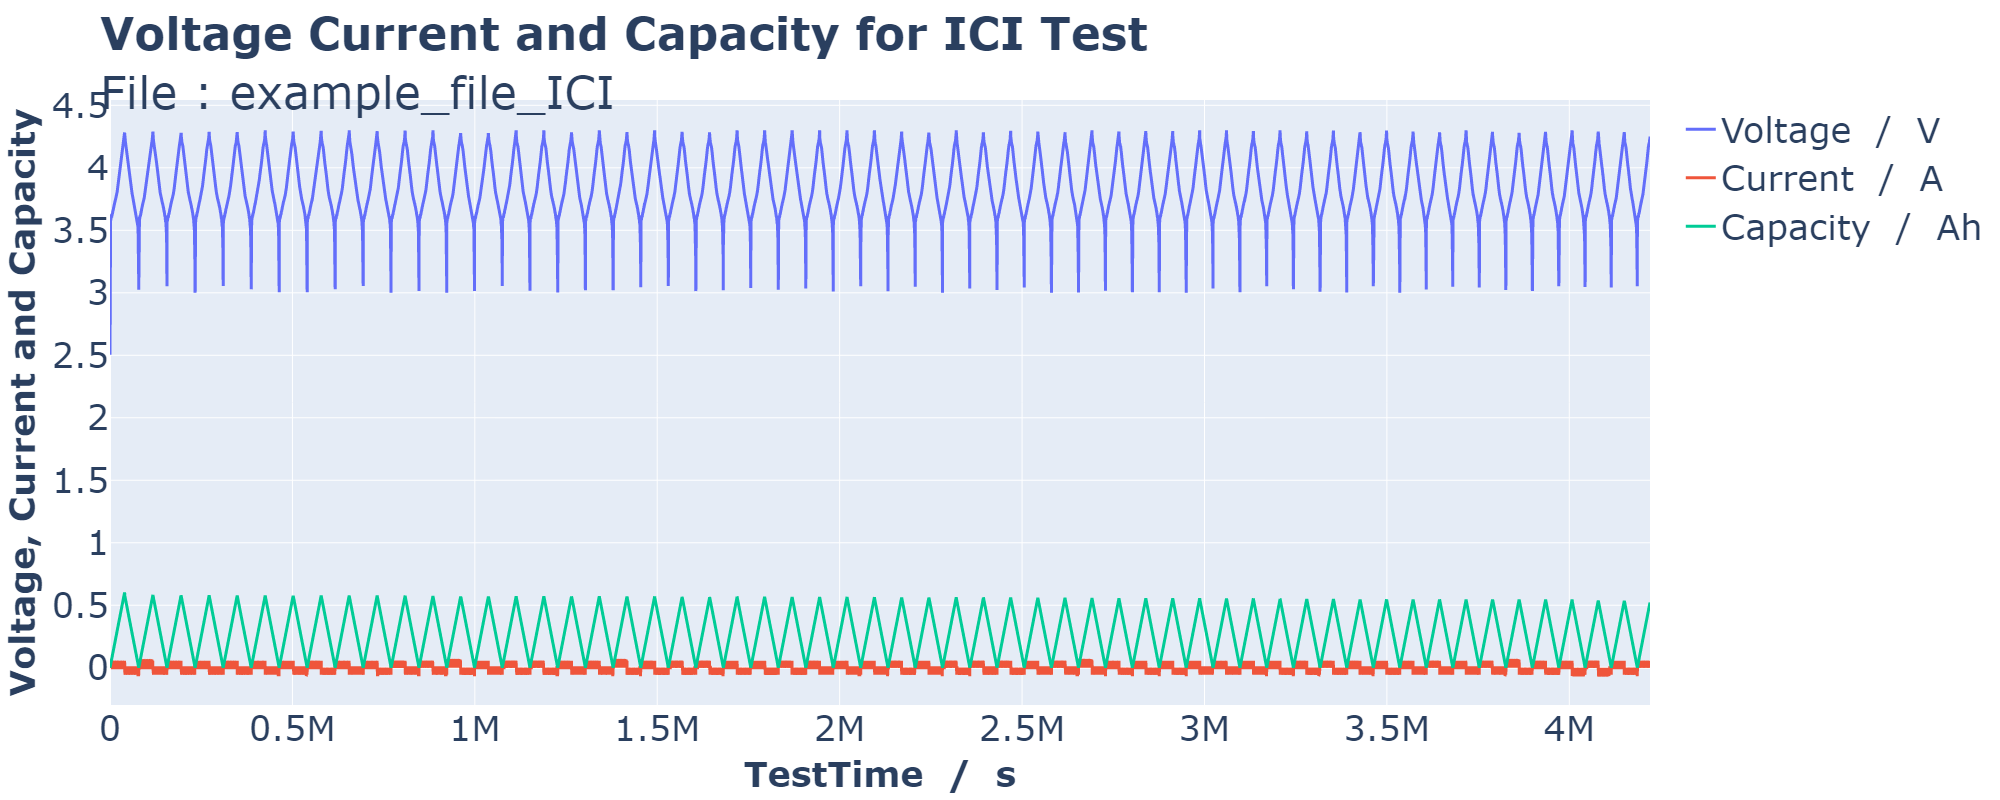

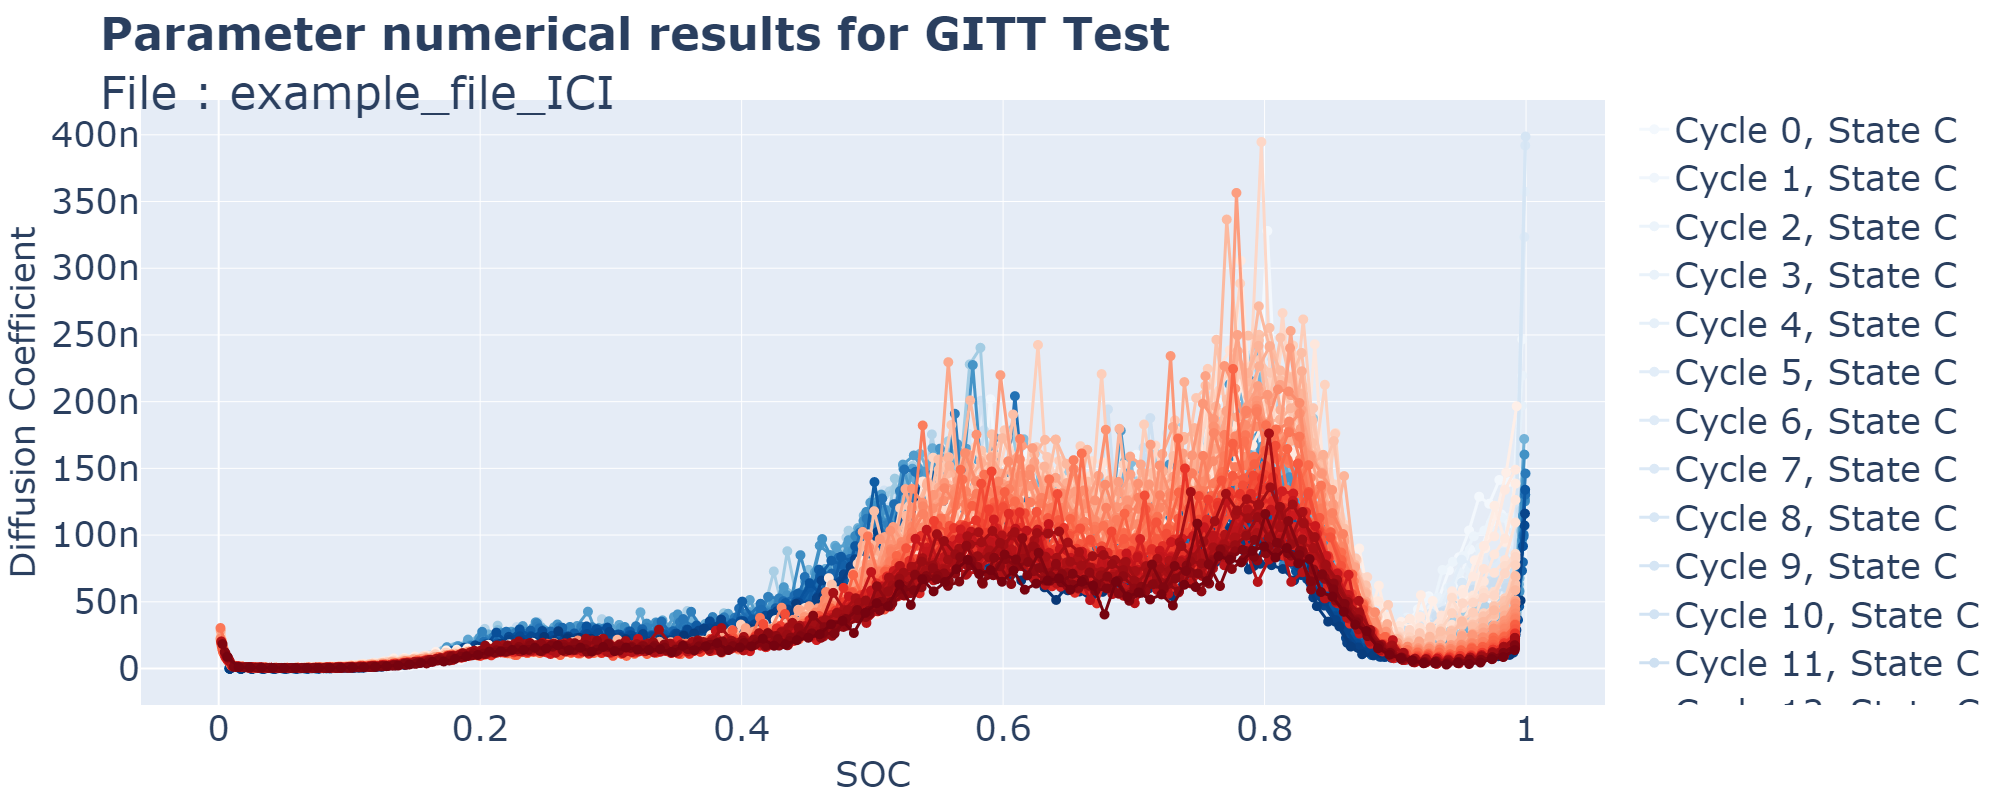

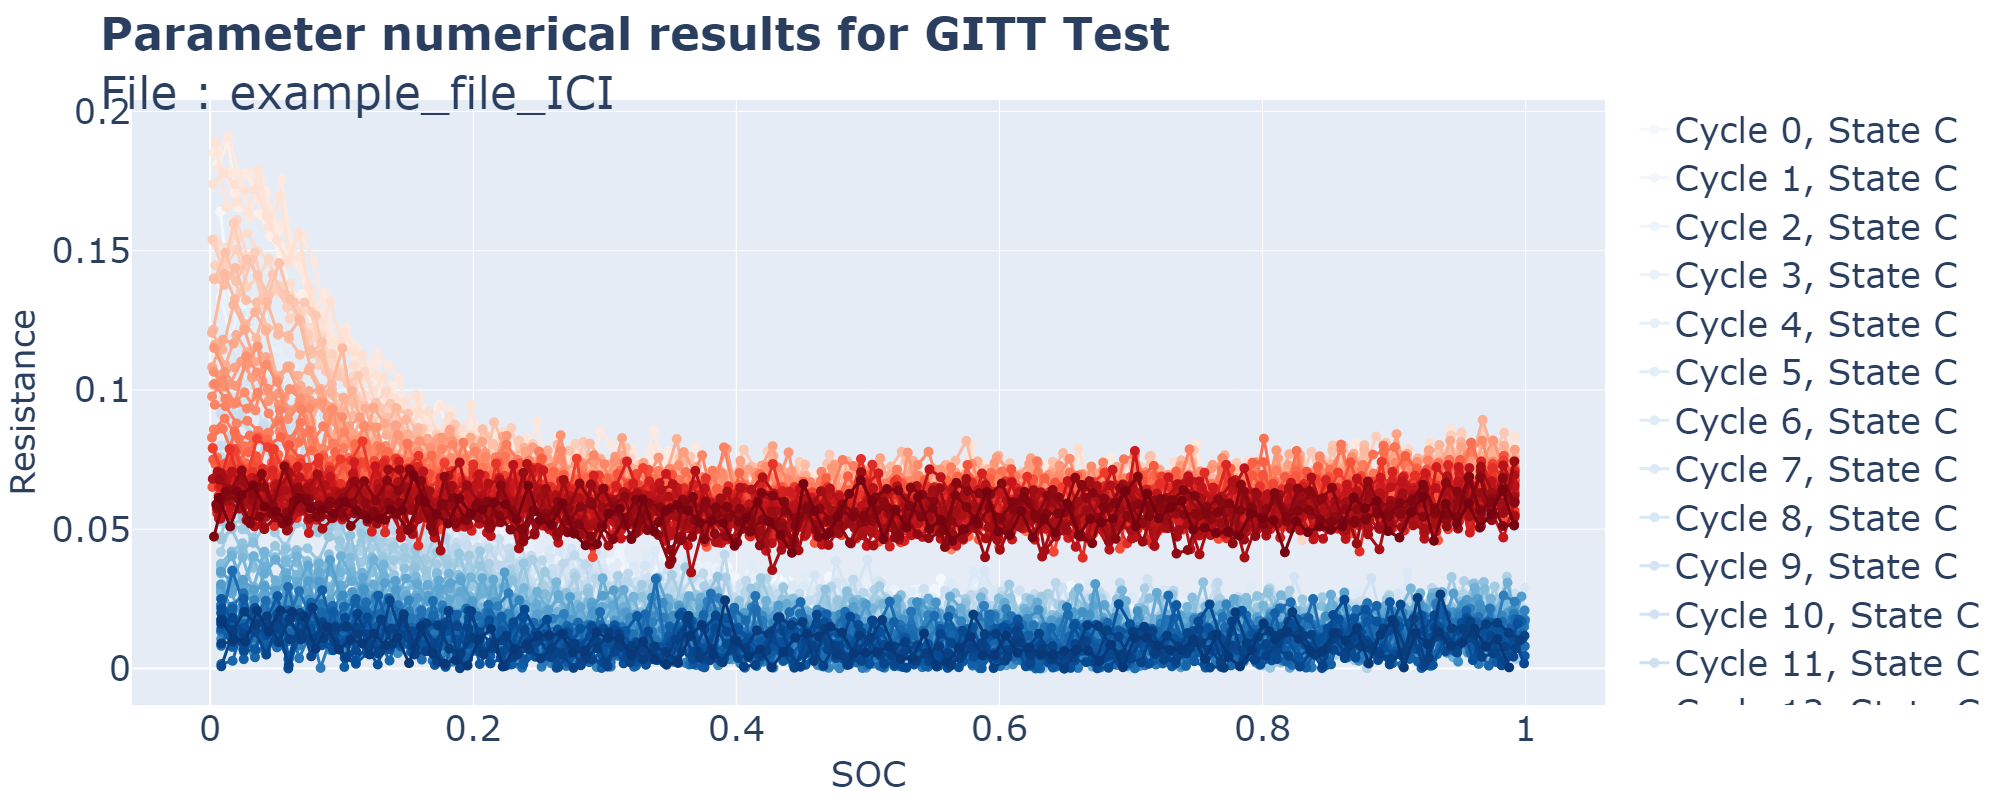

ICI Time : 137.5370650291443
Total Time : 226.01447749137878


In [ ]:
file_path_ICI = 'C:/Examples/example_file_ICI.parquet'

column_names = {'Ewe/V': 'Voltage'}
df, result_dict = process_file(file_path_ICI, column_names=column_names, png=True)

## 
## HPPC Tests

HPPC *(Hybrid Pulse Power Characterization)* is composed of successive charge and discharge pulses are applied to the battery at different SOC  

In this case, the data contains one CCCV cycling followed by an HPPC cycling. The parameters extracted for both charge and discharge pulses are the internal resistance and the pulse power.  
Similarly to the ICI dataset, the column names are not well defined because the dataset has had a shift in its column names (the columns *'Time'* and *'ClimaTemp'* have been merged). Thus, we have to specify the column names and use a debug function as input of the *process_file* function.  

Here, the algorithm only extracts and processes the HPPC cycling data.

File : example_file_HPPC.parquet
Length : 6638226
Preprocessing Time : 51.429892778396606
Find Test Time : 0.30294036865234375
Test : CCCV ; Length : 28649
Test : HPPC ; Length : 26850
       Pulse  Cycle   TestTime       SOC   Voltage State  R_charge  \
Pulse      1      2  2540364.0  0.900844  4.079817     D  0.111250   
Pulse      2      2  2543003.0  0.799412  4.019770     D  0.024969   
Pulse      3      2  2545641.0  0.698158  3.910494     D  0.025031   
Pulse      4      2  2548280.0  0.596766  3.812790     D  0.023334   
Pulse      5      2  2550918.0  0.495523  3.715270     D  0.023680   
Pulse      6      2  2553557.0  0.394644  3.635278     D  0.023428   
Pulse      7      2  2556195.0  0.293388  3.535548     D  0.024168   
Pulse      8      2  2558834.0  0.192012  3.436642     D  0.025245   
Pulse      9      2  2561472.0  0.090768  3.196508     D  0.034912   
Pulse     10      2  2564583.0  0.002342  2.712583     D  0.072719   

       R_discharge    P_charge  P_discharge 

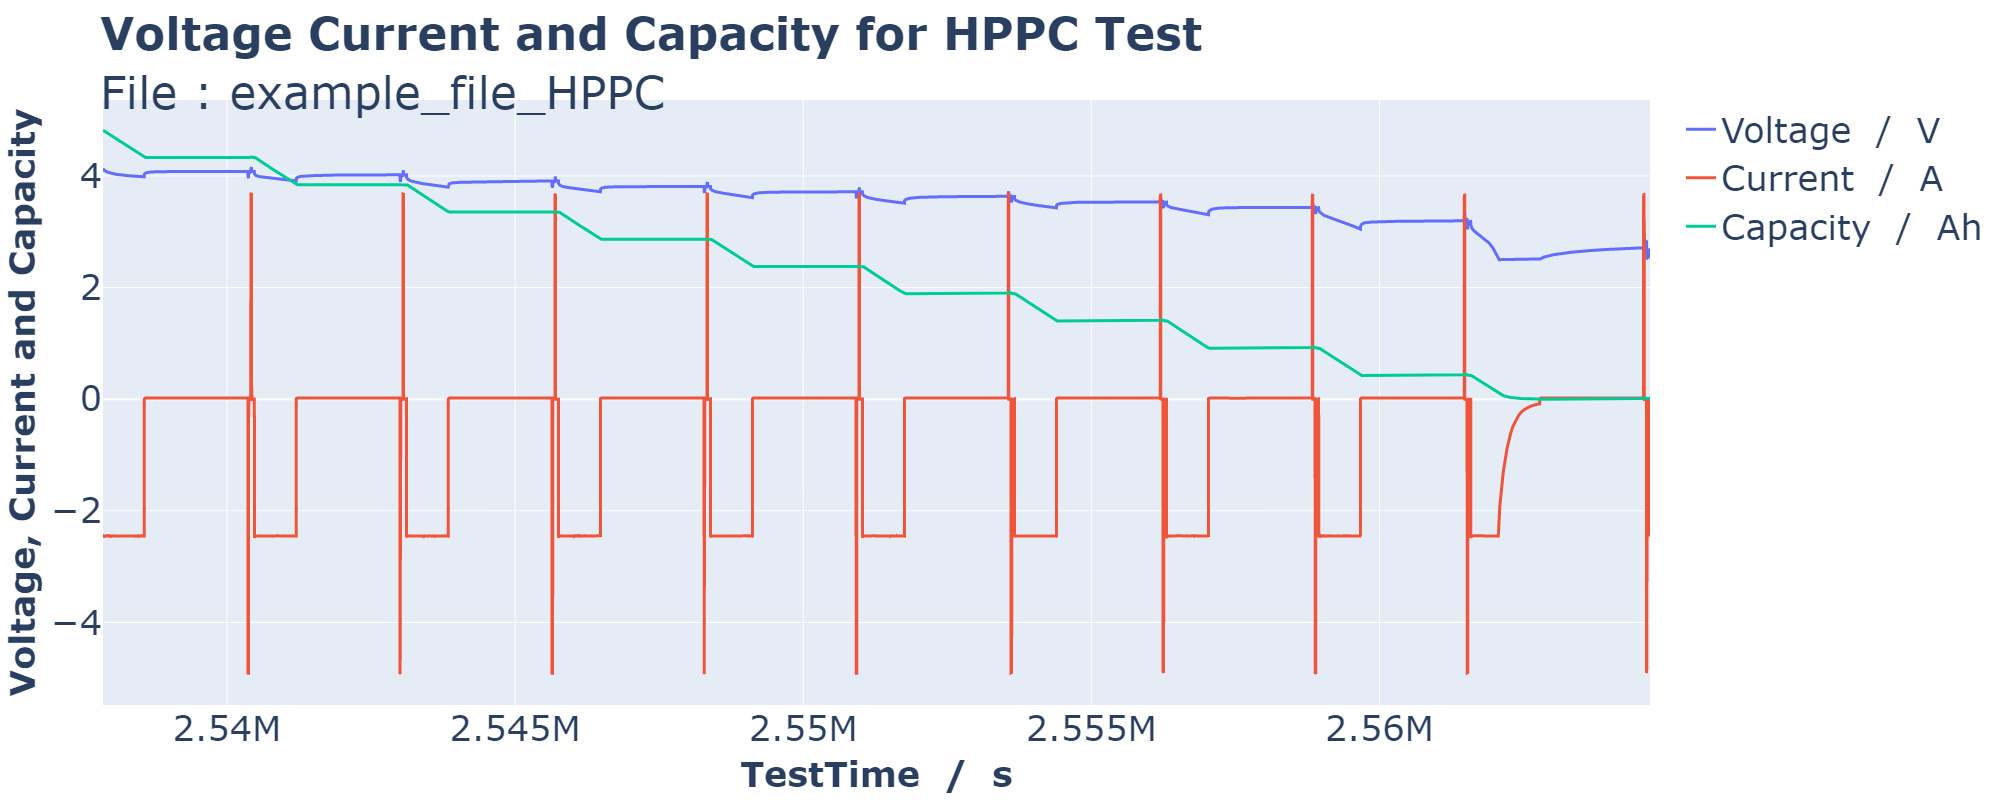

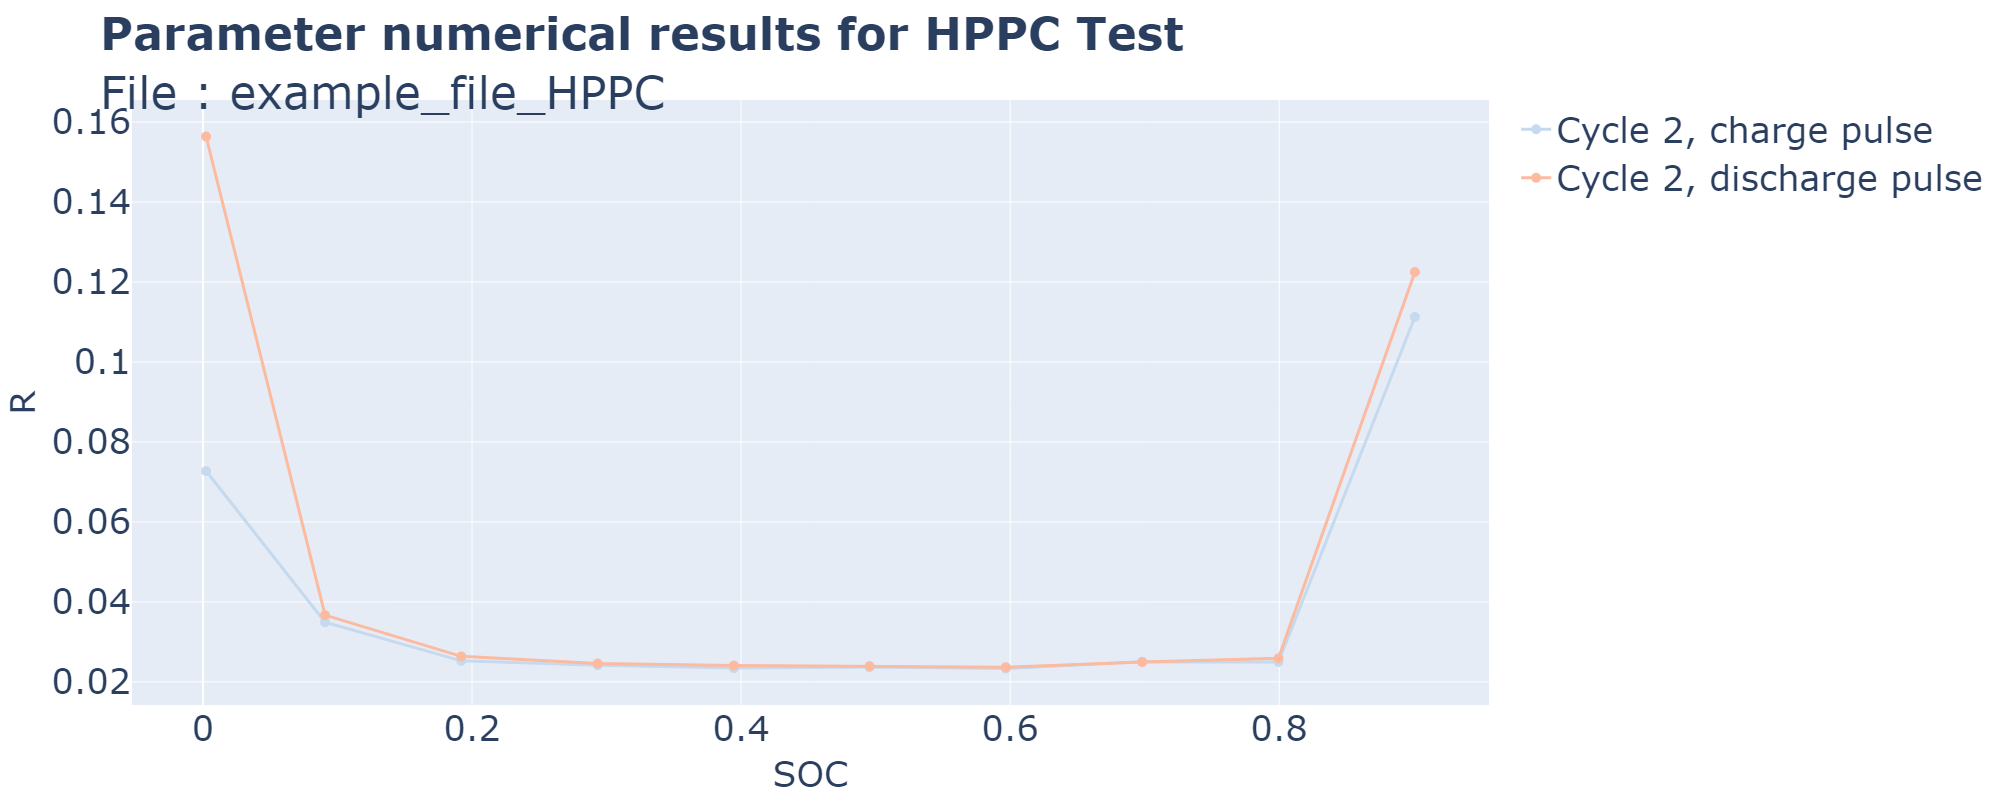

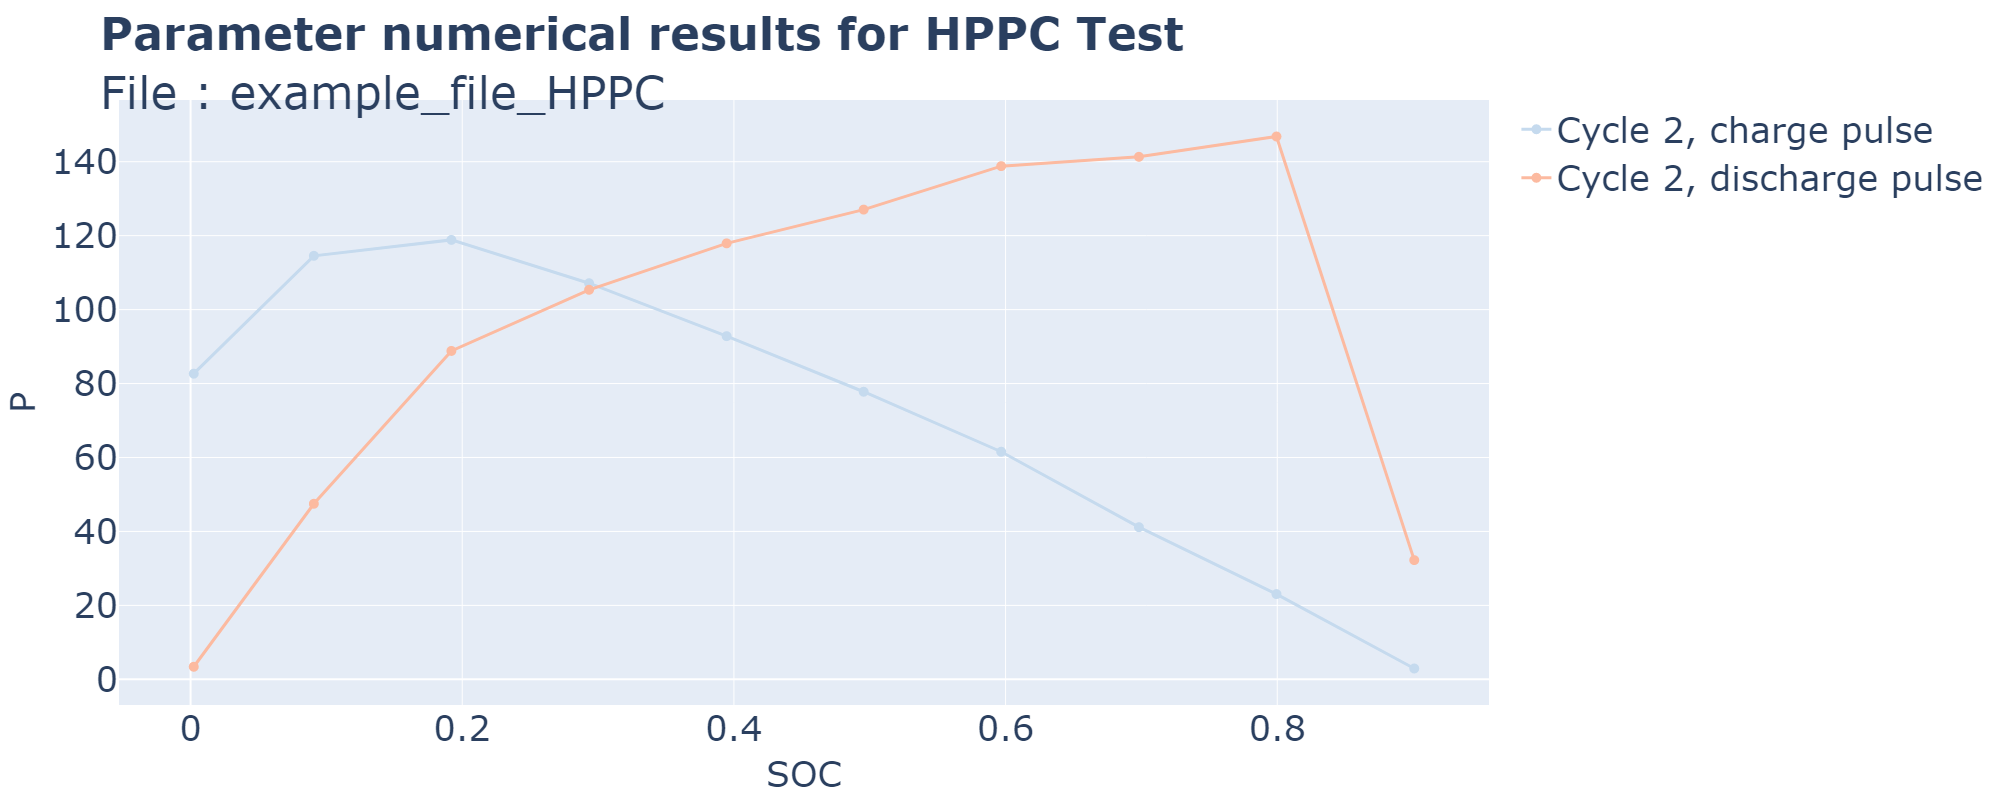

HPPC Time : 2.089202404022217
Total Time : 53.87059736251831


In [ ]:
file_path_HPPC = 'C:/Examples/example_file_HPPC.parquet'

column_names = {
    'Time': 'SysTime',
    'E': 'Current',
    ' W': 'Voltage'
    }

def my_debug_func(df):
    df[['Time', 'ClimaTemp']] = df['Time'].str.extract(r'(.+ \d{2}:\d{2}:\d{2})\.?(\d+)?')
    return df

df, result_dict = process_file(file_path_HPPC, column_names=column_names, debug_func=my_debug_func, png=True)

##  
## dQ/dV Tests

dQ/dV is the capacity derivative over Voltage during a CCCV cycling *(Constant Current Constant Voltage)*
The CCCV cycling is the default type of test if no other test is detected, and leads to a dQ/dV analysis.  
In this case, the data contains only GITT cycling and the parameters extracted are the diffusion coefficients and the internal resistance.

File : example_file_dqdv.parquet
Length : 1269264
Preprocessing Time : 6.852182149887085
Find Test Time : 3.260131359100342
Test : CCCV ; Length : 1243776


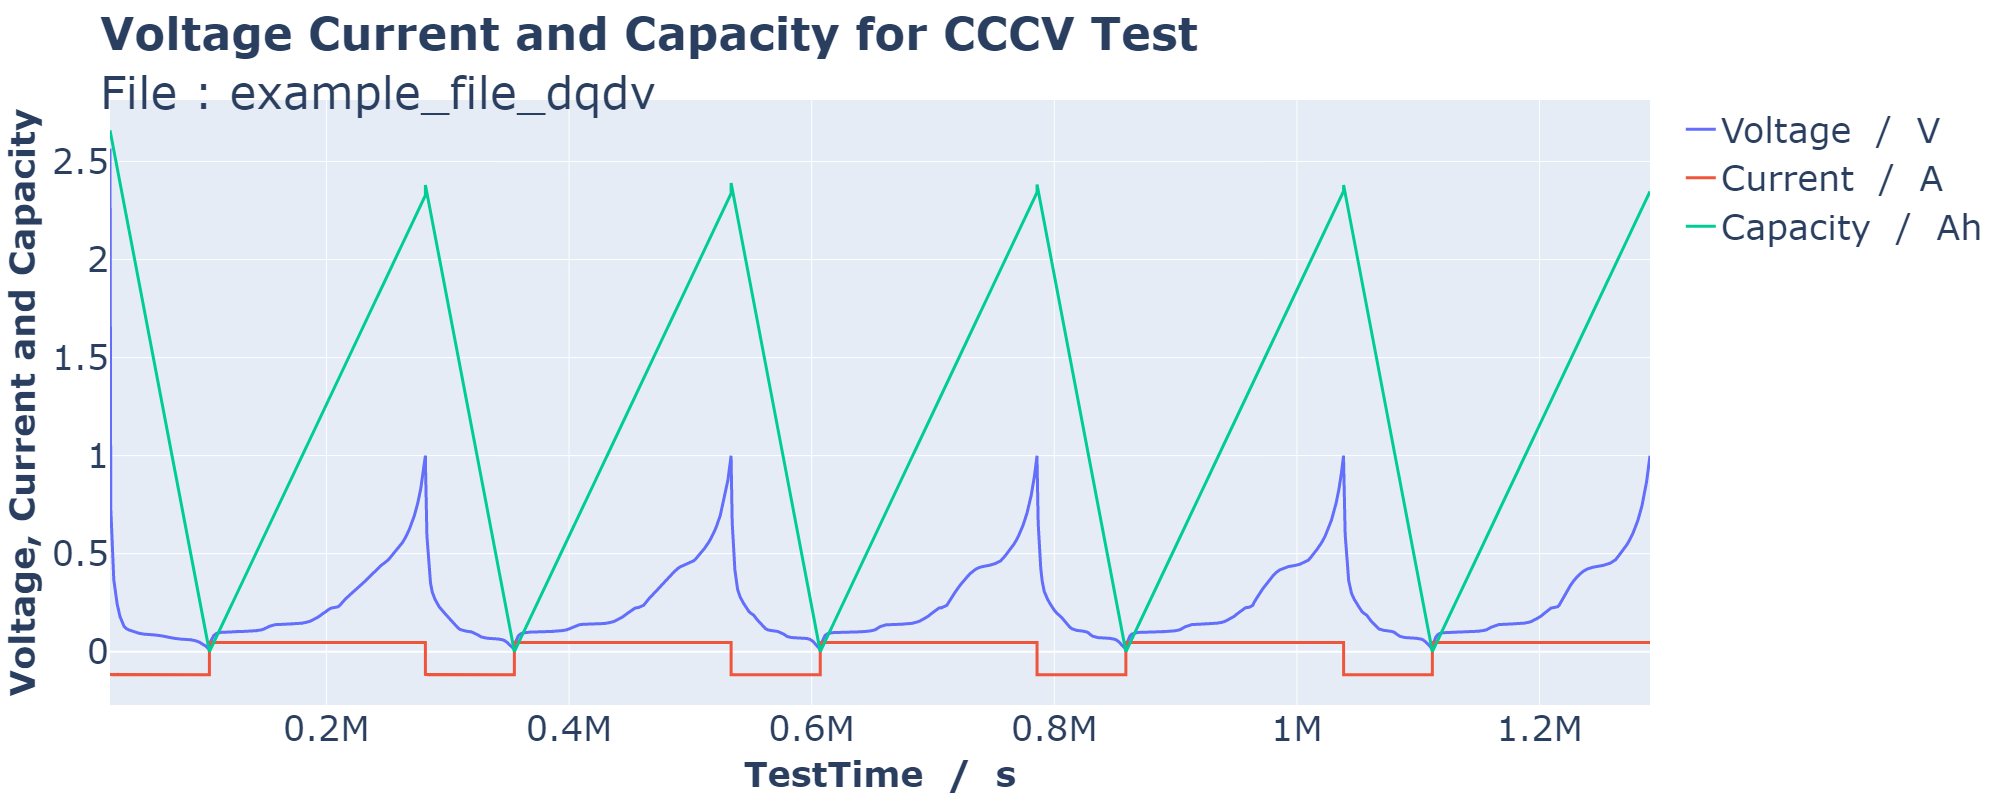

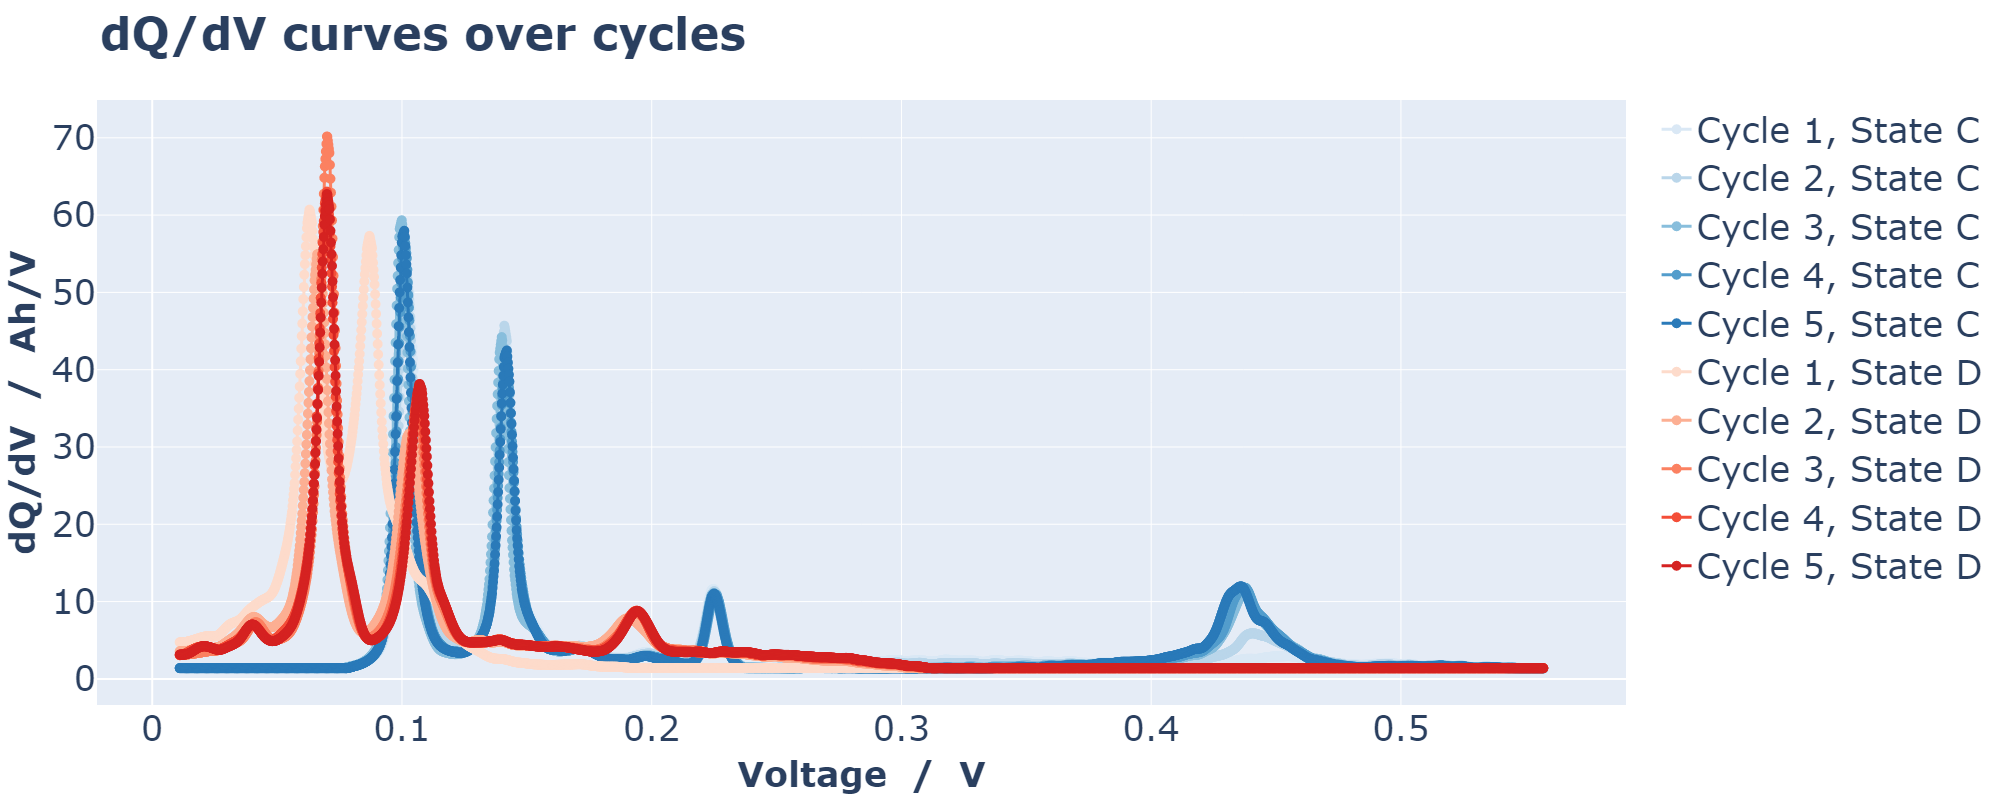

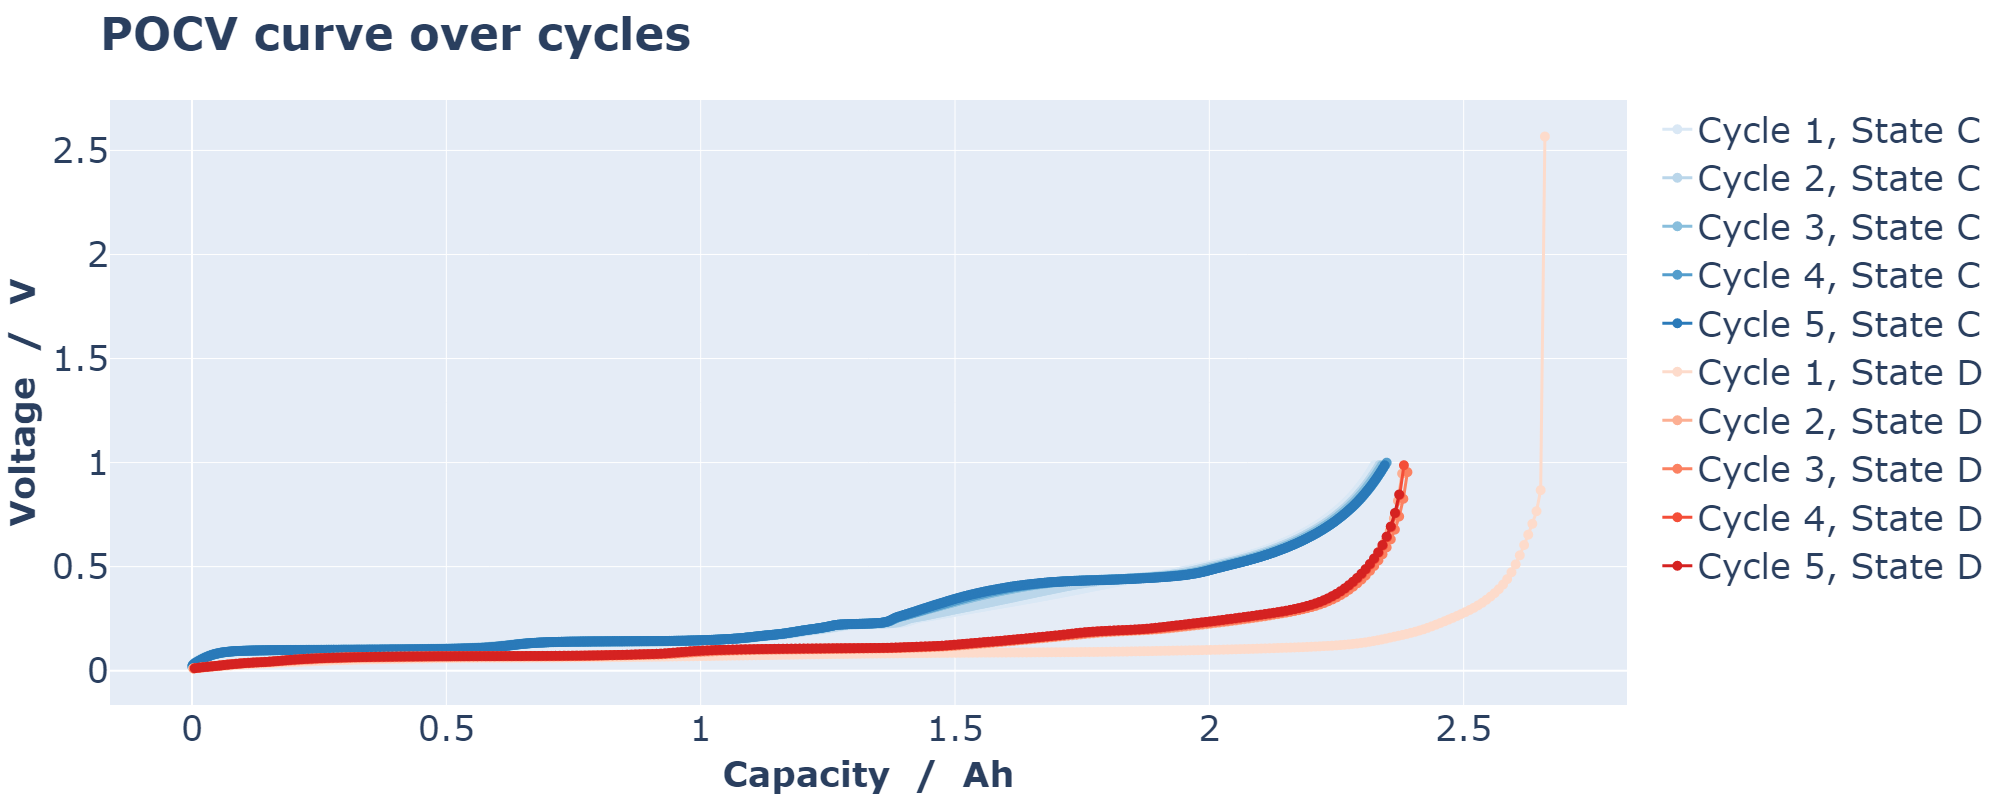

dQ/dV Time : 10.452749967575073
Total Time : 21.334325313568115


In [ ]:
file_path_dqdv = 'C:/Examples/example_file_dqdv.parquet'

df, result_dict = process_file(file_path_dqdv, png=True)